In [14]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from PIL import Image

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/disaster_final/disaster_final'
BATCH_SIZE = 16
IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

DISASTER_TYPES = ['earthquake', 'flood', 'wildfire']
INTENSITIES = ['high', 'medium', 'low']
disaster_to_idx = {name: idx for idx, name in enumerate(DISASTER_TYPES)}
intensity_to_idx = {name: idx for idx, name in enumerate(INTENSITIES)}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
def create_dataset_from_directory(base_path, batch_size=32, target_size=(224, 224)):
    image_paths, disaster_labels, intensity_labels = [], [], []
    search_pattern = os.path.join(base_path, '*', '*', '*.*')
    all_files = glob.glob(search_pattern)
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

    print(f"Scanning {len(all_files)} total files in {base_path} for corruption...")
    for file_path in all_files:
        ext = os.path.splitext(file_path)[1].lower()
        if ext not in valid_extensions or os.path.getsize(file_path) == 0: continue
        try:
            with Image.open(file_path) as img: img.verify()
        except Exception: continue

        parts = os.path.normpath(file_path).split(os.sep)
        if len(parts) >= 3:
            intensity, disaster = parts[-2].lower(), parts[-3].lower()
            if disaster in disaster_to_idx and intensity in intensity_to_idx:
                image_paths.append(file_path)
                disaster_labels.append(disaster_to_idx[disaster])
                intensity_labels.append(intensity_to_idx[intensity])

    print(f"Successfully loaded {len(image_paths)} valid images in {base_path}")

    path_ds = tf.data.Dataset.from_tensor_slices(image_paths)
    label1_ds = tf.data.Dataset.from_tensor_slices(disaster_labels)
    label2_ds = tf.data.Dataset.from_tensor_slices(intensity_labels)
    labels_ds = tf.data.Dataset.zip((label1_ds, label2_ds)).map(lambda l1, l2: {'disaster_output': l1, 'intensity_output': l2})
    path_label_ds = tf.data.Dataset.zip((path_ds, labels_ds))

    def process_path(file_path, labels):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, target_size)
        img.set_shape([target_size[0], target_size[1], 3])
        return img, labels

    dataset = path_label_ds.map(process_path, num_parallel_calls=AUTOTUNE)
    dataset = dataset.apply(tf.data.experimental.ignore_errors())
    dataset = dataset.batch(batch_size).prefetch(buffer_size=2)
    return dataset

print("\nProcessing Datasets for Fine Tuning...")
train_ds = create_dataset_from_directory(os.path.join(DATA_DIR, 'train'), BATCH_SIZE, IMG_SIZE)
train_ds = train_ds.unbatch().shuffle(buffer_size=500).batch(BATCH_SIZE).prefetch(buffer_size=2)
val_ds = create_dataset_from_directory(os.path.join(DATA_DIR, 'validation'), BATCH_SIZE, IMG_SIZE)
test_ds = create_dataset_from_directory(os.path.join(DATA_DIR, 'test'), BATCH_SIZE, IMG_SIZE)



Processing Datasets for Fine Tuning...
Scanning 2245 total files in /content/drive/MyDrive/disaster_final/disaster_final/train for corruption...
Successfully loaded 2245 valid images in /content/drive/MyDrive/disaster_final/disaster_final/train
Scanning 901 total files in /content/drive/MyDrive/disaster_final/disaster_final/validation for corruption...
Successfully loaded 901 valid images in /content/drive/MyDrive/disaster_final/disaster_final/validation
Scanning 465 total files in /content/drive/MyDrive/disaster_final/disaster_final/test for corruption...
Successfully loaded 465 valid images in /content/drive/MyDrive/disaster_final/disaster_final/test


In [18]:
print("\n--- STAGING SURGERY: REPLACING INTENSITY HEAD ---")

# 1. Load your perfectly saved Stage 3 model
old_model = tf.keras.models.load_model('/content/drive/MyDrive/efficientnet_contrastiveloss_checkpoint.keras')
old_model.trainable = False  # Freeze the entire old model!

# 2. Extract the features from exactly where the two heads split
features = old_model.get_layer("shared_features").output

# 3. Build a BRAND NEW Ordinal Intensity Head with UNIQUE NAMES!
h_sev = Dense(512, activation='relu', name='new_sev_dense_1')(features)
h_sev = Dropout(0.4, name='new_sev_drop_1')(h_sev)
h_sev = Dense(256, activation='relu', name='new_sev_dense_2')(h_sev)
h_sev = Dropout(0.4, name='new_sev_drop_2')(h_sev)

# 🚨 1 linear neuron instead of 3 softmax neurons!
new_intensity_output = Dense(1, activation='linear', name='new_intensity_output')(h_sev)

# 4. Create the Upgraded Model
upgraded_model = Model(
    inputs=old_model.input,
    outputs=[old_model.get_layer('disaster_output').output, new_intensity_output]
)

# 5. Compile with Mean Squared Error (Ordinal Math!)
upgraded_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        'disaster_output': 'sparse_categorical_crossentropy',
        'new_intensity_output': 'mse'  # Math forces Low < Med < High
    },
    loss_weights={
        'disaster_output': 0.0, # Completely freeze Disaster mathematically
        'new_intensity_output': 1.0 # 100% focus on new Intensity head
    },
    metrics={
        'disaster_output': 'accuracy',
        'new_intensity_output': 'mae' # Mean Absolute Error
    }
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
]

# 🚨 THE MAGIC FIX: Map the dataset to use the "new_intensity_output" name and turn labels into Decimals!
def prepare_for_surgery(imgs, lbls):
    return imgs, {
        'disaster_output': lbls['disaster_output'],
        'new_intensity_output': tf.cast(lbls['intensity_output'], tf.float32)
    }

print("\n⚙️ Restructuring Dataset Memory Labels...")
train_surgery = train_ds.map(prepare_for_surgery)
val_surgery = val_ds.map(prepare_for_surgery)

print("\n🚀 Training the Upgraded Intensity Math for 15 Epochs...")
history_upgrade = upgraded_model.fit(
    train_surgery,
    validation_data=val_surgery,
    epochs=15,
    callbacks=callbacks
)

# Save the Ultimate Ordinal Model!
upgraded_model.save('/content/drive/MyDrive/Disaster_Model_V_Adam.keras')
print("\n✅ Surgery Model Saved to Google Drive!")



--- STAGING SURGERY: REPLACING INTENSITY HEAD ---

⚙️ Restructuring Dataset Memory Labels...

🚀 Training the Upgraded Intensity Math for 15 Epochs...
Epoch 1/15
    140/Unknown 41s 173ms/step - disaster_output_accuracy: 0.9982 - disaster_output_loss: 0.0082 - loss: 2.3715 - new_intensity_output_loss: 2.3715 - new_intensity_output_mae: 1.1930

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


141/141 ━━━━━━━━━━━━━━━━━━━━ 57s 291ms/step - disaster_output_accuracy: 0.9982 - disaster_output_loss: 0.0083 - loss: 2.3611 - new_intensity_output_loss: 2.3610 - new_intensity_output_mae: 1.1902 - val_disaster_output_accuracy: 0.9810 - val_disaster_output_loss: 0.0468 - val_loss: 0.7045 - val_new_intensity_output_loss: 0.6878 - val_new_intensity_output_mae: 0.7023 - learning_rate: 0.0010
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 79s 275ms/step - disaster_output_accuracy: 0.9961 - disaster_output_loss: 0.0112 - loss: 0.7954 - new_intensity_output_loss: 0.7953 - new_intensity_output_mae: 0.7120 - val_disaster_output_accuracy: 0.9810 - val_disaster_output_loss: 0.0476 - val_loss: 0.5511 - val_new_intensity_output_loss: 0.5594 - val_new_intensity_output_mae: 0.6365 - learning_rate: 0.0010
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 41s 258ms/step - disaster_output_accuracy: 0.9965 - disaster_output_loss: 0.0097 - loss: 0.5563 - new_intensity_output_loss: 0.5562 - new_intensity_output_mae: 0.599


--- EVALUATION on Test Set ---
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 414ms/step - disaster_output_accuracy: 0.8693 - disaster_output_loss: 0.5262 - loss: 0.8840 - new_intensity_output_loss: 0.8832 - new_intensity_output_mae: 0.8200
Overall Test Loss: 0.6997

Extracting predictions for Confusion Matrices...


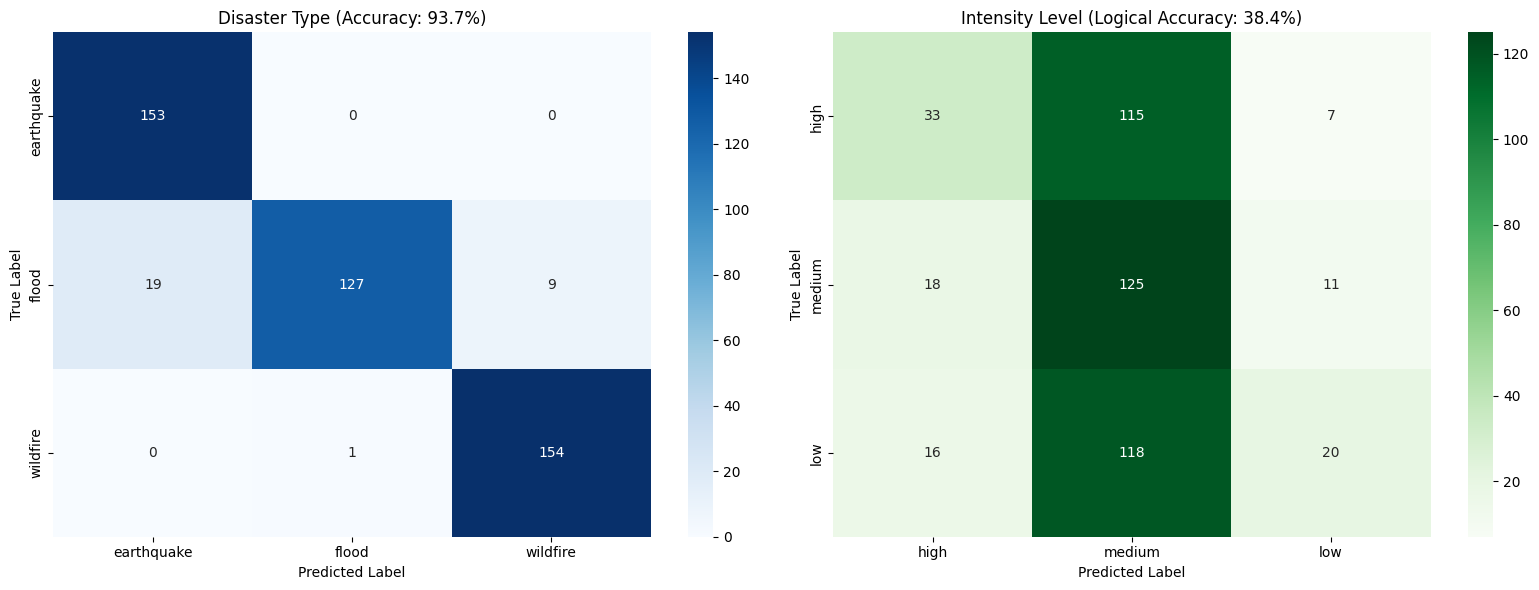

In [20]:
print("\n--- EVALUATION on Test Set ---")

# 🚨 THE FIX: Map the Test Dataset labels so evaluate() doesn't crash!
def prepare_for_surgery(imgs, lbls):
    return imgs, {
        'disaster_output': lbls['disaster_output'],
        'new_intensity_output': tf.cast(lbls['intensity_output'], tf.float32)
    }
test_surgery = test_ds.map(prepare_for_surgery)

# 1. Evaluate on the fixed data
results = upgraded_model.evaluate(test_surgery)
print(f"Overall Test Loss: {results[0]:.4f}")

# 2. Extract Predictions
print("\nExtracting predictions for Confusion Matrices...")
true_disaster, true_intensity = [], []
pred_disaster, pred_intensity = [], []

for images, labels in test_ds:
    # 🚨 NOTE: We extract from labels['intensity_output'] because the raw iterator still uses the base names!
    true_disaster.extend(labels['disaster_output'].numpy())
    true_intensity.extend(labels['intensity_output'].numpy())

    batch_preds = upgraded_model.predict(images, verbose=0)

    # Disaster is still exact buckets
    pred_disaster.extend(np.argmax(batch_preds[0], axis=1))

    # 🚨 Intensity is now a decimal! We round it and restrict it to 0, 1, or 2
    preds_int = np.round(batch_preds[1]).flatten()
    preds_int = np.clip(preds_int, 0, 2).astype(int)
    pred_intensity.extend(preds_int)

# 3. Draw the Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_disaster = confusion_matrix(true_disaster, pred_disaster)
sns.heatmap(cm_disaster, annot=True, fmt='d', cmap='Blues',
            xticklabels=DISASTER_TYPES, yticklabels=DISASTER_TYPES, ax=axes[0])
axes[0].set_title(f'Disaster Type (Accuracy: {results[3]*100:.1f}%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Calculate the logical accuracy for Intensity
logical_acc = np.mean(np.array(true_intensity) == np.array(pred_intensity))

cm_intensity = confusion_matrix(true_intensity, pred_intensity)
sns.heatmap(cm_intensity, annot=True, fmt='d', cmap='Greens',
            xticklabels=INTENSITIES, yticklabels=INTENSITIES, ax=axes[1])
axes[1].set_title(f'Intensity Level (Logical Accuracy: {logical_acc*100:.1f}%)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('surgery_perfect_confusion_matrices.png')
plt.show()


Please select an image file to analyze:


Saving flood_tst3.jpg to flood_tst3 (1).jpg


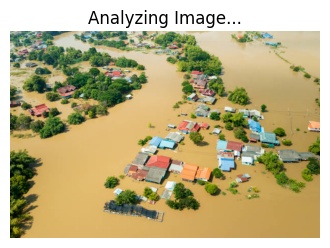


--- 🚨 PREDICTION RESULTS 🚨 ---
👉 Disaster Type:  FLOOD (Confidence: 96.4%)
👉 Severity Level: MEDIUM (AI Calculated Severity Rating: 1.14 out of 2.0)
--------------------------------



In [23]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image

print("Please select an image file to analyze:")
# 1. Prompt you to upload a custom image from your PC
uploaded = files.upload()

for filename in uploaded.keys():
    # Load the image for displaying
    img = Image.open(io.BytesIO(uploaded[filename]))

    # Display the image in the notebook
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Analyzing Image...")
    plt.show()

    # 2. Preprocess the image exactly how the model expects (224x224 size)
    img = img.convert('RGB')
    img_resized = img.resize(IMG_SIZE)
    img_array = image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)  # Make it a 'batch' of 1

    # 3. Force the model to predict!
    # 🚨 Make sure you are using 'upgraded_model', not 'final_model'!
    predictions = upgraded_model.predict(img_array, verbose=0)

    # 4. Decode the predictions into human-readable text

    # --- DISASTER IS STILL PERCENTAGE CATEGORIES ---
    disaster_idx = np.argmax(predictions[0])
    disaster_pred = DISASTER_TYPES[disaster_idx]
    disaster_confidence = np.max(predictions[0]) * 100

    # --- INTENSITY IS NOW A MATHEMATICAL ORDINAL SCALE ---
    # The Model outputs a raw decimal between roughly 0.0 and 2.0
    raw_intensity_score = predictions[1][0][0]

    # We round it to perfectly calculate the bucket (0 = High, 1 = Med, 2 = Low)
    intensity_idx = int(np.round(np.clip(raw_intensity_score, 0, 2)))
    intensity_pred = INTENSITIES[intensity_idx]

    # 5. Print the results
    print(f"\n--- 🚨 PREDICTION RESULTS 🚨 ---")
    print(f"👉 Disaster Type:  {disaster_pred.upper()} (Confidence: {disaster_confidence:.1f}%)")

    # Because Ordinal math doesn't use "Confidence %", we show the actual AI Rating!
    print(f"👉 Severity Level: {intensity_pred.upper()} (AI Calculated Severity Rating: {raw_intensity_score:.2f} out of 2.0)")
    print("-" * 32 + "\n")
